# <b><font color='teal'>Homework 23</font></b>

In [8]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Задача 1. Подгоните полином к набору точек данных и постройте график результатов. Используйте функцию np.polyfit. 

In [3]:
N = 100
# Это независимая переменная, по которой мы будем считать y
x = np.linspace(-10, 10, N)
# Это зависимая переменная, мы считаем ее на основании полинома + добавляем немного "шума" в данные
y = 3 * x**3 + 2 * x**2 + x + np.random.normal(0, 100, N)
# Наша цель - найти полином, который оптимально описывает общую зависимость между x и y.

In [4]:
# Вычислите коэффициенты полинома с помощью функции np.polyfit
# Данная функция принимает следующие параметры:
# - x - независимая переменная
# - y - зависимая переменная
# - deg - степень полинома
# Результат запишите в переменную coef
coef = np.polyfit(x, y, deg=3)
print(coef)

[  3.03502895   1.99651221   1.43606094 -16.01186612]


In [5]:
# Создайте функцию полинома в переменную func
# Используйте функцию np.poly1d с параметром coef
func = np.poly1d(coef)
print(func)

       3         2
3.035 x + 1.997 x + 1.436 x - 16.01


In [6]:
# В переменную y_func вычислите значения с помощью новой функции на основании переменной x
y_func = func(x)
print(y_func)

[-2.86575021e+03 -2.69319514e+03 -2.52775893e+03 -2.36929144e+03
 -2.21764254e+03 -2.07266207e+03 -1.93419990e+03 -1.80210588e+03
 -1.67622988e+03 -1.55642176e+03 -1.44253138e+03 -1.33440859e+03
 -1.23190325e+03 -1.13486522e+03 -1.04314437e+03 -9.56590548e+02
 -8.75053618e+02 -7.98383438e+02 -7.26429867e+02 -6.59042765e+02
 -5.96071991e+02 -5.37367404e+02 -4.82778864e+02 -4.32156229e+02
 -3.85349360e+02 -3.42208115e+02 -3.02582354e+02 -2.66321935e+02
 -2.33276719e+02 -2.03296565e+02 -1.76231331e+02 -1.51930877e+02
 -1.30245063e+02 -1.11023747e+02 -9.41167888e+01 -7.93740481e+01
 -6.66453839e+01 -5.57806554e+01 -4.66297219e+01 -3.90424428e+01
 -3.28686772e+01 -2.79582845e+01 -2.41611240e+01 -2.13270549e+01
 -1.93059365e+01 -1.79476281e+01 -1.71019890e+01 -1.66188785e+01
 -1.63481558e+01 -1.61396802e+01 -1.58433110e+01 -1.53089075e+01
 -1.43863290e+01 -1.29254347e+01 -1.07760839e+01 -7.78813594e+00
 -3.81145005e+00  1.30411447e+00  7.70869834e+00  1.55524423e+01
  2.49854870e+01  3.61579

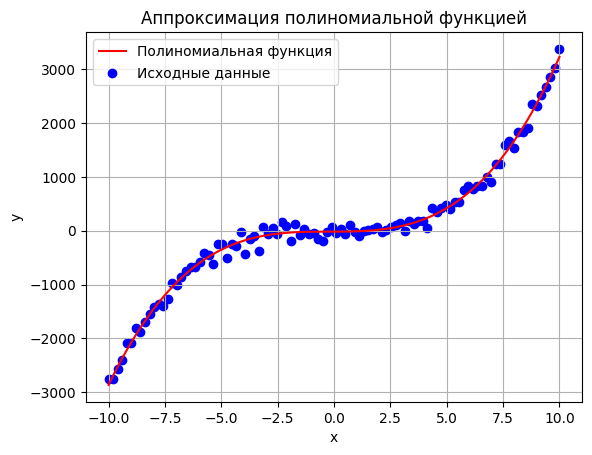

In [9]:
# Постройте график получившейся функции (plot) + график изначальных точек (scatterplot) на одной системе координат
plt.plot(x, y_func, label='Полиномиальная функция', color='red')
plt.scatter(x, y, label='Исходные данные', color='blue')
plt.legend()
plt.title('Аппроксимация полиномиальной функцией')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

Задача 2. На основании датасета titanic создайте возрастные группы и рассчитайте коэффициент выживаемости для каждой комбинации возрастной группы и класса.

In [12]:
# Загрузите датасет titanic из библиотеки seaborn в переменную df_titanic
titanic = pd.read_csv('..//data//titanic.csv')
display(titanic.head())

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [13]:
# В список bins запишите границы возрастов
bins = [0, 12, 18, 35, 60, 100]

In [14]:
# В список labels запишите названия для групп
labels = ['Child', 'Teenager', 'Adult', 'Middle-aged', 'Senior']

In [16]:
# С помощью функции pd.cut() создайте новый столбец age_group и запишите туда возрастные группы
titanic['age_group'] = pd.cut(titanic['Age'], bins=bins, labels=labels)
display(titanic.head())

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,age_group
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,Adult
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,Middle-aged
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,Adult
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,Adult
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,Adult


In [31]:
# Коэффициент выживаемости - это доля пассажиров, которые выжили в каждой группе.\
# В переменную survived_rate вычислите коэффициент выживаемости для каждой возрастной группы и класса внутри группы
survived_rate = titanic.groupby(['age_group', 'Pclass'])['Survived'].agg(
    Pclass='count',
    Survived='sum',
    
)
survived_rate['k'] = survived_rate['Survived'] / survived_rate['Pclass']
display(survived_rate)

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_20316\2837899537.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survived_rate = titanic.groupby(['age_group', 'Pclass'])['Survived'].agg(


Pclass  Survived         k
age_group   Pclass                            
Child       1            4         3  0.750000
            2           17        17  1.000000
            3           58        23  0.396552
Teenager    1           12        11  0.916667
            2           12         6  0.500000
            3           63        18  0.285714
Adult       1           71        52  0.732394
            2          101        44  0.435644
            3          287        71  0.247387
Middle-aged 1          114        67  0.587719
            2           51        19  0.372549
            3           71         6  0.084507
Senior      1           15         3  0.200000
            2            3         1  0.333333
            3            8         1  0.125000